# Laboratorio: espacios discretos y continuos en Gymnasium

Este laboratorio compara tres tipos de problemas de aprendizaje por refuerzo usando **Gymnasium** y **Stable-Baselines3**:

1. **FrozenLake**: observaciones discretas + acciones discretas.
2. **LunarLander**: observaciones continuas + acciones discretas.
3. **Pendulum**: observaciones continuas + acciones continuas.

El objetivo principal no es obtener el mejor agente posible, sino observar cómo cambian `observation_space`, `action_space` y el algoritmo apropiado.


## 1. Instalación


In [ ]:
!pip -q uninstall -y dopamine-rl gym
!pip -q install "gymnasium[box2d,classic-control,toy-text]" stable-baselines3 pygame imageio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 75.7 MB/s eta 0:00:00


## 2. Importaciones


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN, SAC
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy

## 3. Función auxiliar

Antes de entrenar, inspeccionaremos explícitamente los espacios. `Discrete(n)` representa un conjunto finito de valores; `Box(...)` representa un subconjunto continuo de $\mathbb{R}^n$.


In [ ]:
# Esta es una función para describir los diferentes aspectos de un environment cualquiera. Esto es para entender las acciones y el espacio
def describe_env(env_id):
    env = gym.make(env_id)
    print("Entorno:", env_id)
    print("Observation space:", env.observation_space)
    print("Action space:", env.action_space)
    obs, info = env.reset(seed=42)
    print("Observación inicial:", obs)
    print("Acción aleatoria:", env.action_space.sample())
    env.close()


# Caso 1 — FrozenLake: estado discreto + acción discreta

`FrozenLake-v1` funciona como un GridWorld sencillo. El agente ocupa una casilla de la cuadrícula y el estado puede codificarse mediante un entero. Las acciones también forman un conjunto finito: izquierda, abajo, derecha y arriba.

Para que el ejemplo sea más fácil de entrenar usamos `is_slippery=False`, eliminando la aleatoriedad del hielo.

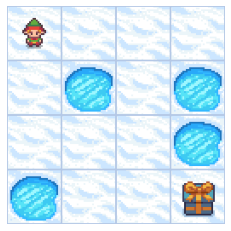

In [ ]:
# Descripción del environment que vamos a crear:
describe_env("FrozenLake-v1")

Entorno: FrozenLake-v1
Observation space: Discrete(16)
Action space: Discrete(4)
Observación inicial: 0
Acción aleatoria: 1


# Caso 2 — LunarLander: estado continuo + acción discreta

En `LunarLander-v3` la observación es un vector de variables físicas continuas: posición, velocidad, orientación, velocidad angular y contactos de las patas. Sin embargo, el motor se controla mediante un conjunto discreto de acciones.

Por tanto:

$$\mathcal{S}\subset\mathbb{R}^8, \qquad \mathcal{A}=\{0,1,2,3\}$$

Este es el caso clásico en el que DQN resulta natural: la red recibe un vector continuo y produce un valor $Q(s,a)$ para cada acción discreta.

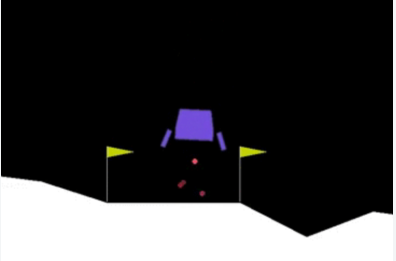

| Índice | Variable de estado | Descripción |
|---|---|---|
| **`0`** | **Posición `x`** | Coordenada horizontal (el objetivo está en `0`). |
| **`1`** | **Posición `y`** | Coordenada vertical. |
| **`2`** | **Velocidad `x`** | Velocidad lineal horizontal. |
| **`3`** | **Velocidad `y`** | Velocidad lineal vertical. |
| **`4`** | **Ángulo** | Orientación o inclinación del módulo en radianes. |
| **`5`** | **Velocidad angular** | Velocidad con la que está rotando el módulo. |
| **`6`** | **Contacto pierna izquierda** | Booleano (`0` o `1`) que indica contacto con el suelo. |
| **`7`** | **Contacto pierna derecha** | Booleano (`0` o `1`) que indica contacto con el suelo. |

In [ ]:
describe_env("LunarLander-v3")


Entorno: LunarLander-v3
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Observación inicial: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]
Acción aleatoria: 3


# Caso 3 — Pendulum: estado continuo + acción continua

`Pendulum-v1` tiene observaciones continuas y también una acción continua. El agente controla el torque aplicado al péndulo.

Aquí ya no podemos enumerar todas las acciones posibles. Por ello DQN no es apropiado. Utilizaremos **SAC (Soft Actor-Critic)**, diseñado para espacios de acción `Box`.


In [ ]:
describe_env("Pendulum-v1")


Entorno: Pendulum-v1
Observation space: Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)
Action space: Box(-2.0, 2.0, (1,), float32)
Observación inicial: [-0.14995256  0.9886932  -0.12224312]
Acción aleatoria: [-0.42366242]
